 Copyright © Sorbonne University.

 This source code is licensed under the MIT license found in the
 LICENSE file in the root directory of this source tree.

# PLDAC - RL TABULAIRE


In this notebook, we will code a naive actor-critic algorithm in the tabular case using q-tables instead of the value function v.


## Install libraries

Installs the necessary Python and system libraries

In [1]:
try:
    from easypip import easyimport
except ModuleNotFoundError:
    from subprocess import run
    assert run(["pip", "install", "easypip"]).returncode == 0, "Could not install easypip"
    from easypip import easyimport

easyimport("swig")
easyimport("bbrl_utils").setup(maze_mdp=True)

import os
from pathlib import Path
from typing import List, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from bbrl_gymnasium.envs.maze_mdp import MazeMDPEnv
from bbrl_utils.notebook import tqdm
from mazemdp.mdp import Mdp
from mazemdp.toolbox import egreedy, egreedy_loc, sample_categorical, softmax
from mazemdp import random_policy
import bbrl_gymnasium  # noqa: F401

Matplotlib backend: module://matplotlib_inline.backend_inline


/home/sigaud/.local/lib/python3.9/site-packages/bbrl_utils/notebook.py:46: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm  # noqa: F401


In [2]:
# matplotlib.use("TkAgg")

from functools import partial
!pip install optuna
import optuna
import yaml
import hydra
from omegaconf import OmegaConf, DictConfig

import seaborn as sns
sns.set_theme()
import logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Step 1: Updating the naive Actor-critic algorithm with Q-values

We consider the naive actor-critic algorithm with a categorical policy.  
The algorithm learns a critic with the standard temporal difference mechanism  
using a learning rate \(\alpha_{critic}\).

We consider a **Q-value-based critic** \(Q(s, a)\) instead of a value-based critic \(V(s)\), which allows the algorithm to estimate the value of taking action \(a\) from state \(s\).  


---

## Critic Update Rules

We implement four different update rules for the Q-values:

1. **SARSA Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]$

   This rule follows the **on-policy** approach, where the next action is drawn according to the policy.  

2. **Q-learning Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - max_a Q(s_t, a)]$
   
   This rule follows the **off-policy** approach, where the best possible action is chosen greedily.  

3. **"Mean" SARSA Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - \Sigma_a \pi(a|s_t)  Q(s_t, a)]$
   
   This rule leverages the **expected value** of the Q-function over all actions, weighted by the current policy.  

4. **Fourth Update Rule**  
   $Q(s_t, a_t) ← Q(s_t, a_t) + alpha-critic [r_{t+1} + \gamma max_a Q(s_{t+1}, a) - Q(s_t, a_t)]$  
   This rule uses a one-step update towards the maximum Q-value of the next state.  
   
   

---

## Actor Update

To update the actor, the general idea is the same, using the temporal difference error with another learning rate $\alpha_{actor}$.

However, naively applying the same learning rule would not ensure that the probabilities of all actions in a state sum to 1.
Besides, when the temporal difference error $\delta_t$ is negative, it may happen that the probability of an action gets negative or null, which raises an issue when applying renormalization.

So, instead of applying the naive rule, we apply the following one:
$$
\pi_{temp}(a_t|s_t) =  \begin{cases}
\pi^{(i)}(a_t|s_t) + \alpha_{actor} \delta_t & \mathrm{if } \pi^{(i)}(a_t|s_t) + \alpha_{actor} \delta_t > 10^{-8}\\
10^{-8} & \mathrm{otherwise.} \\
\end{cases}
$$

Then we can apply renormalization so that the probabilities of actions still sum to 1, with
$$
\forall a, \pi^{(i+1)}(a|s_t) = \frac{\pi_{temp}^{(i+1)}(a|s_t)} {\sum_{a'} \pi_{temp}^{(i+1)}(a'|s_t)}
$$ with
$$
\pi_{temp}^{(i+1)}(a|s_t) =  \begin{cases}
\pi_{temp}(a|s_t) & \mathrm{if } a = a_t\\
\pi^{(i)}(a|s_t) & \mathrm{otherwise.} \\
\end{cases}
$$

---

## Implementation:

We provide a Python implementation of the naive actor-critic algorithm with Q-values using the four update rules.  


---


In [3]:
def renormalize(
    mdp: MazeMDPEnv,
    policy: np.array,
    state: np.array,
) -> None:
    """
    Renormalize the probability of actions so that the sum of probabilities over actions is always 1.
    We made sure in the calling function that the probabilities of action never get negative when they are decreased.
    :param mdp: the mdp the agent is working in (to get the number of actions)
    :param policy: the current policy, before normalization
    :param state: the state where the actions need to be renormalized
    :return: nothing
    """

    policy[state] = policy[state] / np.sum(policy[state])


In [4]:
def perform_episode(
    mdp: MazeMDPEnv,
    policy: np.array,
    q: np.array,
    alpha_critic: float,
    alpha_actor: float,
    update_type: int,
    render: bool = True,
) -> int:
    """
    Perform an episode on the given mdp with the given policy using Q-values.
    :param update_type: int indicating the chosen update rule (1, 2, 3, 4).
    :return: the number of steps before it stops
    """
    state, _ = mdp.reset(uniform=True) # reninit env, get initial state
    terminated = False
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):
        action = sample_categorical(policy[state])  #draw action from the policy
        next_state, reward, terminated, truncated, _ = mdp.step(action)

        # max Q-value for the next state
        max_q_next = np.max(q[next_state])

        # next action according to the current policy (for SARSA)
        next_action = sample_categorical(policy[next_state])

        # TD error (delta) based on the selected update type
        if update_type == 1:
            # 1: SARSA update rule
            delta = reward + mdp.gamma * q[next_state, next_action] * (1 - terminated) - q[state, action]

        elif update_type == 2:
            # 2: Q-learning update rule
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - np.max(q[state])

        elif update_type == 3:
            # 3: MEAN SARSA update rule
            sum = np.sum(policy[state] * q[state])
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - sum

        elif update_type == 4:
            # 4: Fourth update rule
            delta = reward + mdp.gamma * max_q_next * (1 - terminated) - q[state, action]
        else:
            raise ValueError("Invalid update type")

        # Update the Q-value with the delta
        q[state, action] += alpha_critic * delta

        # Update the policy with the new Q-values using the softmax function
        policy_temp = policy[state, action] + alpha_actor * delta
        policy[state, action] = max(policy_temp, 1e-8)
        renormalize(mdp, policy, state)

        # Move to the next state
        state = next_state
        steps += 1
        value_norm = np.linalg.norm(q)

    return value_norm, steps

Here comes the main actor-critic function. It should take the shown parameters as input and output a list of value norms and a list of number of steps,
corresponding to the evolution of these quantities through learning

In [5]:
def actor_critic_q(
    mdp: MazeMDPEnv,
    nb_episodes: int,
    alpha_critic: float,
    alpha_actor: float,
    update_type: int,
    render: bool = True,
) -> np.array:
    """
    Perform actor-critic training over a number of episodes with Q-values.
    :param update_type: int indicating the chosen update rule (1, 2, 3, 4).
    :return: a list of norm of Q values and a list of number of steps of episodes
    """
    # Initialize Q-values to zero
    q = np.zeros((mdp.nb_states, mdp.action_space.n)) # MAIN CHANGES FROM PREVIOUSLY

    # Initialize uniform policy
    policy = np.ones((mdp.nb_states, mdp.action_space.n)) / mdp.action_space.n

    # Store the number of steps and norms
    nb_steps = []
    value_norms = []

    for ep in range(nb_episodes):
        value_norm, steps = perform_episode(mdp, policy, q, alpha_critic, alpha_actor, update_type, render)
        value_norms.append(value_norm)
        nb_steps.append(steps)

    return value_norms, nb_steps

## Provide a plot function

Your plot function should show the evolution through time of number of steps the agent takes to find the reward in the maze.
If your algorithm works, this number of steps should decrease through time.

Your plot function should also show a mean and a standard deviation (or some more advanced statistics) over a collection of learning runs.
Make sure that your figure complies with [The figure checklist](https://master-dac.isir.upmc.fr/The_figure_checklist.pdf).

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_steps(
    nb_runs: int = 5,
    nb_episodes: int = 20,
    alpha_critic: float = 0.01,
    alpha_actor: float = 0.01,
    render: bool = True
) -> None:
    """
    Plot the performance of the Actor-Critic algorithm over multiple runs with different update rules.
    Shows the mean and standard deviation of the number of steps per episode for each update rule.
    Also provides a summary table with mean and standard deviation values.
    :param nb_episodes: the number of episodes
    :param alpha_critic: the learning rate of the critic
    :param alpha_actor: the learning rate of the actor
    :param render: whether training should be rendered
    :param nb_runs: number of runs to perform
    :return: nothing
    """
    update_names = ["SARSA", "Q-learning", "Mean SARSA", "Fourth Rule"]
    all_results = []
    summary = []

    for update_type in range(1, 5):
        all_steps = []
        all_vals = []

        for run in range(nb_runs):
            vals, nb_steps = actor_critic_q(mdp, nb_episodes, alpha_critic, alpha_actor, update_type, render)
            all_steps.append(nb_steps)
            all_vals.append(vals)

        # Convert to numpy arrays
        all_steps = np.array(all_steps)
        mean_steps = np.mean(all_steps, axis=0)
        std_steps = np.std(all_steps, axis=0)
        all_results.append((update_names[update_type - 1], mean_steps, std_steps))
        summary.append([update_names[update_type - 1], np.mean(mean_steps), np.std(mean_steps)])

    # Create summary table
    summary_df = pd.DataFrame(summary, columns=["Update Rule", "Mean Steps", "Standard Deviation"])
    print("\nSummary Table:\n", summary_df)
    print("nb_episodes:", nb_episodes)
    
    # Plotting results
    plt.figure(figsize=(12, 8))
    plt.title("Actor-Critic Performance - Comparison of Update Rules")
    plt.xlabel("Episode")
    plt.ylabel("Number of Steps")
    plt.grid(True, linestyle="--", alpha=0.6)

    for name, mean_steps, std_steps in all_results:
        plt.plot(mean_steps, label=f"{name} - Mean Steps")
        plt.fill_between(range(nb_episodes), mean_steps - std_steps, mean_steps + std_steps, alpha=0.2)

    plt.legend(loc="upper right")
    plt.savefig("actor_critic_comparison.pdf")
    plt.show()


## Actor-critic hyper-parameters

To represent the hyper-parameters of the experiments performed in this notebook, we suggest using the dictionary below.
This dictionary can be read using omegaconf.
Using it is not mandatory.
You can also change the value of hyper-parameters or environment parameters at will.

## Test your code

The code for testing what you did so far is provided below.

In [30]:
# default given initially
ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
        "name": "MazeMDP-v0",
        "width": 5,
        "height": 5,
        "ratio": 0.0,
        "render_mode": "rgb_array",
        },

    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",

    "nb_episodes": 30,
    "render": False, # True, #
    "nb_repeats": 5,

    "alpha_critic": 0.5,
    "alpha_actor": 0.5,
    }

def make_mdp(cfg):
    mdp = gym.make(cfg.mdp.name, kwargs={"width": cfg.mdp.width, "height": cfg.mdp.height, "ratio": cfg.mdp.ratio}, render_mode=cfg.mdp.render_mode)
    mdp = mdp.unwrapped
    return mdp

cfg=OmegaConf.create(ac_params)
mdp = make_mdp(cfg) # the mdp is made once and for all, this is an ugly global variable

In [ ]:
plot_steps(nb_runs=cfg.nb_repeats, nb_episodes=cfg.nb_episodes, alpha_actor=cfg.alpha_actor, alpha_critic=cfg.alpha_critic)

# print("average v value:", v_vals.mean())

### More tests...


Summary Table:
    Update Rule  Mean Steps  Standard Deviation
0        SARSA     71.4345            6.178318
1   Q-learning     67.3120            7.283865
2   Mean SARSA     68.3445            5.185898
3  Fourth Rule     70.2600            9.649368
nb_episodes: 20


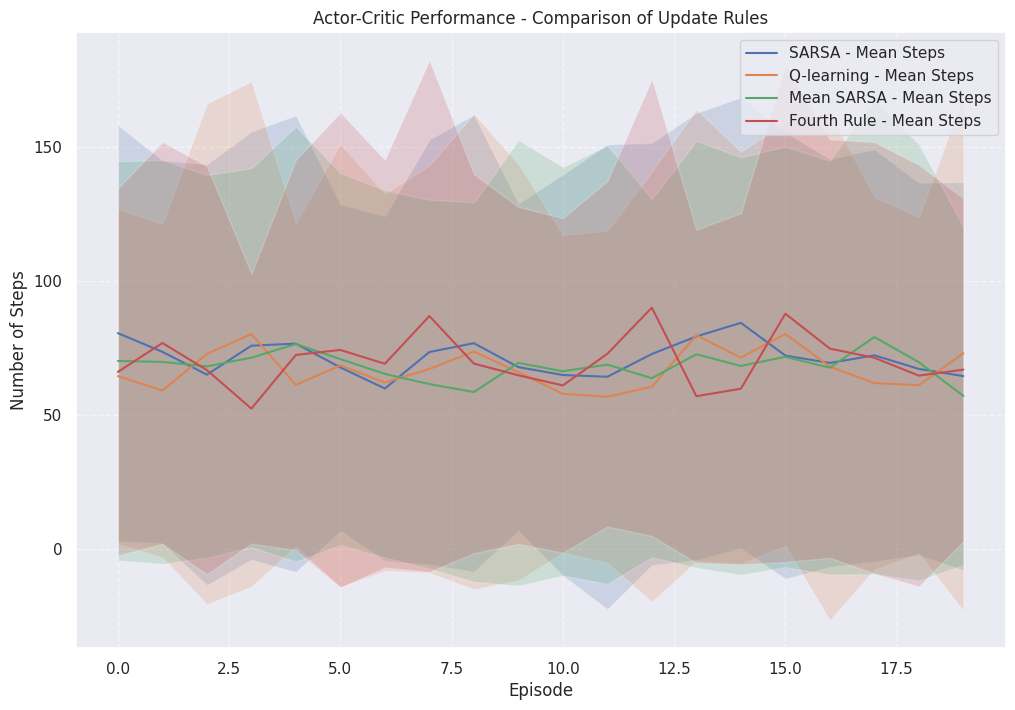

Temps d'exécution pour 100 runs : 0:00:14.721451


In [10]:
ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
        "name": "MazeMDP-v0",
        "width": 5,
        "height": 5,
        "ratio": 0.2,
        "render_mode": "rgb_array",
        },

    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",

    "nb_episodes": 100,
    "render": False, # True, #
    "nb_repeats": 5,

    "alpha_critic": 0.8, # ICI ON AUGMENTE LEARNING RATE DU CRITIC (because drives actor's LR)
    "alpha_actor": 0.5,
    }

cfg=OmegaConf.create(ac_params)
mdp = make_mdp(cfg) # the mdp is made once and for all, this is an ugly global variable

import time
from datetime import timedelta
N = 100

start_time = time.time()  # mesurer temps
plot_steps(nb_runs=N)
end_time = time.time()

elapsed_time = timedelta(seconds=(end_time - start_time))
print(f"Temps d'exécution pour {N} runs : {elapsed_time}")

# print("average v value:", v_vals.mean())


Summary Table:
    Update Rule  Mean Steps  Standard Deviation
0        SARSA    103.9160           11.927464
1   Q-learning    105.7200           12.771644
2   Mean SARSA    102.5915           12.120848
3  Fourth Rule    104.0630           11.584839
nb_episodes: 20


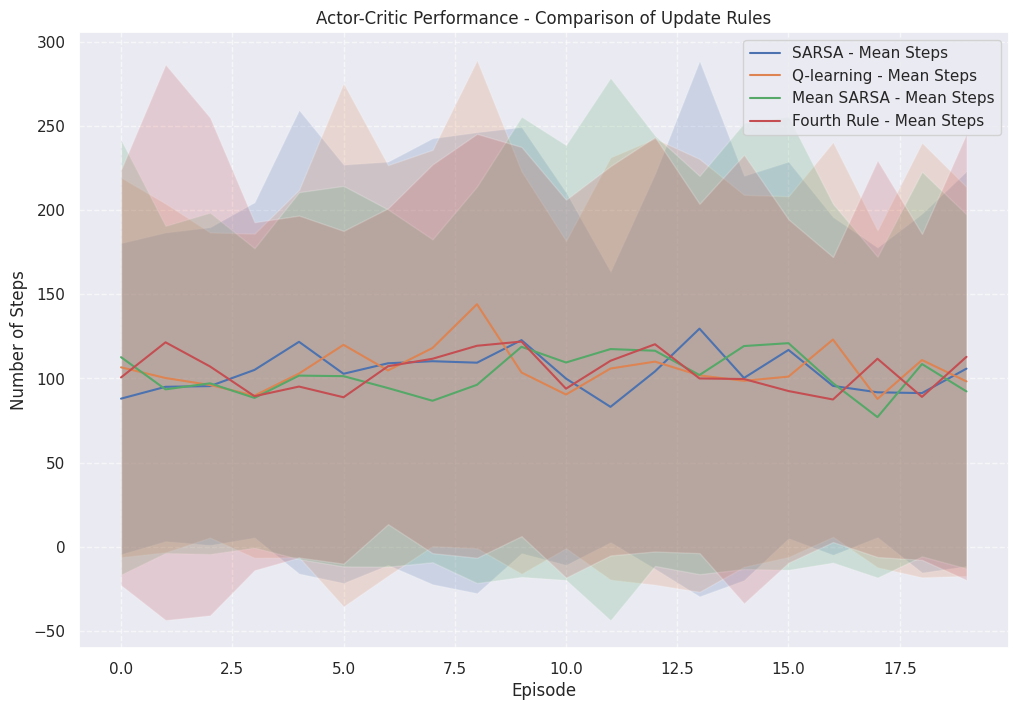

Temps d'exécution pour 100 runs : 0:00:21.808775


In [11]:
ac_params = {
    "save_curves": False,
    "save_heatmap": True,
    "mdp": {
        "name": "MazeMDP-v0",
        "width": 5,
        "height": 5,
        "ratio": 0.2,
        "render_mode": "rgb_array",
        },

    "log_dir": "./tmp",
    "video_dir": "./tmp/videos",

    "nb_episodes": 100,
    "render": False, # True, #
    "nb_repeats": 5,

    "alpha_critic": 0.5, # CAS inverse du précédent (à titre d'observation)
    "alpha_actor": 0.8,
    }

cfg=OmegaConf.create(ac_params)
mdp = make_mdp(cfg) # the mdp is made once and for all, this is an ugly global variable

import time
from datetime import timedelta
N = 100

start_time = time.time()  # mesurer temps
plot_steps(nb_runs=N)
end_time = time.time()

elapsed_time = timedelta(seconds=(end_time - start_time))
print(f"Temps d'exécution pour {N} runs : {elapsed_time}")

# print("average v value:", v_vals.mean())

Test avec gamma = 0.9

Summary Table:
    Update Rule  Mean Steps  Standard Deviation
0        SARSA      94.028           10.891472
1   Q-learning      97.308           10.454088
2   Mean SARSA      95.533           10.399454
3  Fourth Rule      92.256            6.955457
nb_episodes: 20


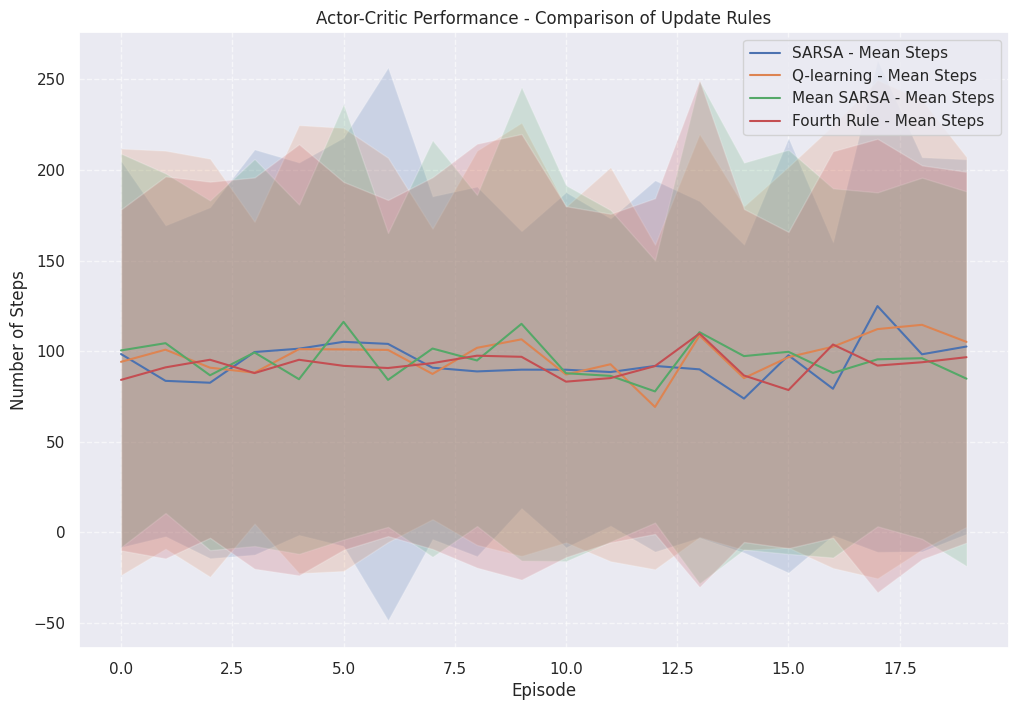

Temps d'exécution pour 100 runs avec gamma = 0.9 : 0:00:20.005879

Test avec gamma = 0.95


KeyboardInterrupt: 

In [12]:
gammas = [0.9, 0.95, 0.99]  # Valeurs de gamma à tester

for gamma in gammas:
    print(f"Test avec gamma = {gamma}")

    ac_params = {
        "save_curves": False,
        "save_heatmap": True,
        "mdp": {
            "name": "MazeMDP-v0",
            "width": 5,
            "height": 5,
            "ratio": 0.2,
            "render_mode": "rgb_array",
            "gamma": gamma,  # Ajouter gamma ici
        },
        "log_dir": "./tmp",
        "video_dir": "./tmp/videos",
        "nb_episodes": 100,
        "render": False,
        "nb_repeats": 5,
        "alpha_critic": 0.8,
        "alpha_actor": 0.5,
    }

    cfg = OmegaConf.create(ac_params)
    mdp = make_mdp(cfg)  # Création de l'environnement avec la nouvelle valeur de gamma

    import time
    from datetime import timedelta
    N = 100

    start_time = time.time()  # mesurer temps
    plot_steps(nb_runs=N)
    end_time = time.time()

    elapsed_time = timedelta(seconds=(end_time - start_time))
    print(f"Temps d'exécution pour {N} runs avec gamma = {gamma} : {elapsed_time}\n")
